## Bước 0: Upload file dữ liệu Titanic lên Colab

Chạy ô lệnh bên dưới, sau đó chọn file titanic (.csv) từ máy tính để upload lên Colab.

In [ ]:
# Import thư viện dùng để upload file trên Google Colab
from google.colab import files

uploaded = files.upload()

for ten_file in uploaded.keys():
    print("Đã upload file:", ten_file)


Saving titanic_disaster.csv to titanic_disaster.csv
Đã upload file: titanic_disaster.csv


In [ ]:
# Import các thư viện cần thiết cho toàn bộ bài
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc file dữ liệu vừa upload (thay tên file bên dưới nếu bạn upload file có tên khác)
ten_file_du_lieu = 'titanic_disaster.csv'
df = pd.read_csv(ten_file_du_lieu)

# Chuẩn hóa tên cột về chữ thường và bỏ khoảng trắng thừa
# (một số file titanic tải từ Kaggle đặt tên cột viết hoa như 'Age', 'Sex', 'Pclass'...)
df.columns = [ten_cot.strip().lower() for ten_cot in df.columns]

# Đổi tên cột 'cabin' thành 'deck' cho khớp với tên dùng trong bài (nếu file có cột này)
df = df.rename(columns={'cabin': 'deck'})

print("Đọc dữ liệu thành công!")
print("Danh sách các cột hiện có:")
print(df.columns.tolist())


Đọc dữ liệu thành công!
Danh sách các cột hiện có:
['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'deck', 'embarked']


# PHẦN 1: TIỀN XỬ LÝ VÀ TRỰC QUAN HÓA DỮ LIỆU (6.0 Điểm)

## Câu 1: Nạp và Khám phá dữ liệu (1.0 điểm)

- In ra 5 dòng đầu tiên của tập dữ liệu.
- In ra thông tin tổng quan của dữ liệu (hàm info()) để xem kiểu dữ liệu và số lượng giá trị Non-Null của từng cột.

In [ ]:
# In ra 5 dòng đầu tiên của tập dữ liệu
df.head()


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,deck,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# In ra thông tin tổng quan: kiểu dữ liệu và số lượng giá trị Non-Null từng cột
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  deck         204 non-null    object 
 11  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Câu 2: Xử lý giá trị khuyết (1.5 điểm)

- Đếm số lượng giá trị khuyết ở mỗi cột.
- Xóa hoàn toàn cột 'deck' khỏi DataFrame (vì có quá nhiều giá trị khuyết).
- Điền các giá trị khuyết ở cột 'age' bằng Trung bình (Mean) tuổi của tất cả hành khách.

In [ ]:
# Đếm số lượng giá trị khuyết (missing values) ở mỗi cột
df.isnull().sum()


,0
passengerid,0
survived,0
pclass,0
name,0
sex,0
age,177
sibsp,0
parch,0
ticket,0
fare,0


In [ ]:
# Xóa hoàn toàn cột 'deck' vì có quá nhiều giá trị khuyết
# Dùng errors='ignore' để tránh lỗi nếu file dữ liệu của bạn không có sẵn cột này
df = df.drop(columns=['deck'], errors='ignore')

print("Đã xóa cột 'deck'. Các cột còn lại:")
print(df.columns.tolist())


Đã xóa cột 'deck'. Các cột còn lại:
['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'embarked']


In [ ]:
# Tính giá trị trung bình (mean) của cột 'age'
gia_tri_trung_binh_tuoi = df['age'].mean()

# Điền các giá trị khuyết ở cột 'age' bằng giá trị trung bình vừa tính
df['age'] = df['age'].fillna(gia_tri_trung_binh_tuoi)

print("Giá trị trung bình tuổi dùng để điền khuyết:", gia_tri_trung_binh_tuoi)
print("Số giá trị khuyết còn lại ở cột 'age':", df['age'].isnull().sum())


Giá trị trung bình tuổi dùng để điền khuyết: 29.69911764705882
Số giá trị khuyết còn lại ở cột 'age': 0


## Câu 3: Phân tích và Trực quan hóa (2.0 điểm)

- Vẽ biểu đồ cột (Count plot) thể hiện số lượng hành khách sống sót ('survived') phân chia theo giới tính ('sex').
- Vẽ biểu đồ phân bố (Histogram/KDE) thể hiện phân bố độ tuổi ('age') của hành khách.
- Tính ma trận tương quan giữa các biến số ('survived', 'pclass', 'age', 'fare') và vẽ Heatmap.

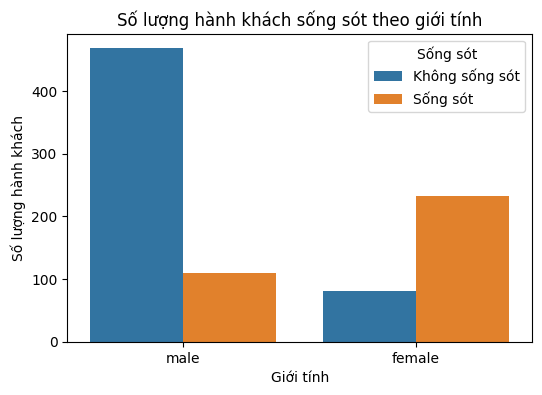

In [ ]:
# Vẽ biểu đồ cột thể hiện số lượng hành khách sống sót phân chia theo giới tính
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sex', hue='survived')
plt.title('Số lượng hành khách sống sót theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng hành khách')
plt.legend(title='Sống sót', labels=['Không sống sót', 'Sống sót'])
plt.show()


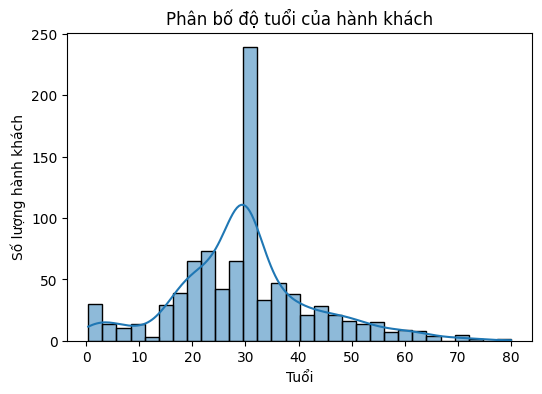

In [ ]:
# Vẽ biểu đồ phân bố (Histogram kết hợp KDE) thể hiện phân bố độ tuổi hành khách
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='age', kde=True, bins=30)
plt.title('Phân bố độ tuổi của hành khách')
plt.xlabel('Tuổi')
plt.ylabel('Số lượng hành khách')
plt.show()


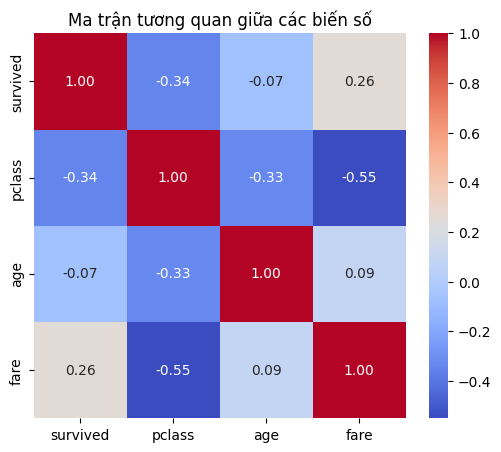

In [ ]:
# Chọn các cột số để tính ma trận tương quan
cac_cot_so = ['survived', 'pclass', 'age', 'fare']
ma_tran_tuong_quan = df[cac_cot_so].corr()

# Vẽ Heatmap biểu diễn ma trận tương quan
plt.figure(figsize=(6, 5))
sns.heatmap(ma_tran_tuong_quan, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số')
plt.show()


## Câu 4: Mã hóa dữ liệu (1.5 điểm)

- Dùng Label Encoding (map dictionary) để chuyển cột 'sex' ('male', 'female') thành số (0, 1).
- Dùng One-Hot Encoding (pd.get_dummies) cho cột 'embarked' và gộp vào DataFrame chính.

In [ ]:
# Label Encoding cho cột 'sex': male -> 0, female -> 1
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

df[['sex']].head()


,sex
0,0
1,1
2,1
3,1
4,0


In [ ]:
# One-Hot Encoding cho cột 'embarked'
embarked_encoded = pd.get_dummies(df['embarked'], prefix='embarked')

# Gộp các cột One-Hot Encoding vào DataFrame chính
df = pd.concat([df, embarked_encoded], axis=1)

# Xóa cột 'embarked' gốc vì đã được mã hóa
df = df.drop(columns=['embarked'], errors='ignore')

df.head()


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked_C,embarked_Q,embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,False,True


# PHẦN 2: XÂY DỰNG MÔ HÌNH HỌC SÂU CƠ BẢN (4.0 Điểm)

## Câu 5: Chuẩn bị dữ liệu cho Học sâu (1.5 điểm)

- Tạo biến X chứa 3 cột đặc trưng: 'pclass', 'sex', 'age'. Biến y chứa cột 'survived'.
- Dùng train_test_split để chia dữ liệu train/test theo tỷ lệ 80% - 20%.
- Chuẩn hóa (Scale) X_train và X_test bằng StandardScaler.

In [ ]:
# Import các thư viện cần thiết từ sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Tạo biến X chứa 3 đặc trưng: pclass, sex, age
X = df[['pclass', 'sex', 'age']]

# Tạo biến y chứa nhãn cần dự đoán: survived
y = df['survived']

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)


Kích thước X: (891, 3)
Kích thước y: (891,)


In [ ]:
# Chia dữ liệu thành tập huấn luyện (80%) và tập kiểm thử (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Số mẫu tập train:", X_train.shape[0])
print("Số mẫu tập test:", X_test.shape[0])


Số mẫu tập train: 712
Số mẫu tập test: 179


In [ ]:
# Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()

# fit_transform trên tập train, transform trên tập test
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Đã chuẩn hóa xong tập X_train và X_test")


Đã chuẩn hóa xong tập X_train và X_test


## Câu 6: Xây dựng mạng Nơ-ron nhân tạo (ANN) (2.5 điểm)

- Khởi tạo mô hình Sequential().
- Thêm lớp ẩn (Dense) với 16 nơ-ron, hàm kích hoạt 'relu', input_shape phù hợp với 3 đặc trưng.
- Thêm lớp đầu ra với 1 nơ-ron, hàm kích hoạt 'sigmoid'.
- Compile mô hình với optimizer 'adam', loss 'binary_crossentropy', metrics ['accuracy'].
- Huấn luyện mô hình với 20 epochs, sau đó đánh giá trên tập test.

In [ ]:
# Import các thư viện cần thiết từ TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Khởi tạo mô hình Sequential
model = Sequential()

# Thêm lớp ẩn với 16 nơ-ron, hàm kích hoạt relu
# input_shape=(3,) vì có 3 đặc trưng đầu vào: pclass, sex, age
model.add(Dense(16, activation='relu', input_shape=(3,)))

# Thêm lớp đầu ra với 1 nơ-ron, hàm kích hoạt sigmoid (phân loại nhị phân)
model.add(Dense(1, activation='sigmoid'))

# Xem tóm tắt cấu trúc mô hình
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile mô hình
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Đã compile mô hình thành công")


Đã compile mô hình thành công


In [ ]:
# Huấn luyện mô hình với tập train trong 20 epochs
lich_su_huan_luyen = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test)
)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.6208 - loss: 0.6605 - val_accuracy: 0.7263 - val_loss: 0.6316
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7121 - loss: 0.6321 - val_accuracy: 0.7654 - val_loss: 0.6069
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7416 - loss: 0.6084 - val_accuracy: 0.7821 - val_loss: 0.5843
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7640 - loss: 0.5853 - val_accuracy: 0.7877 - val_loss: 0.5622
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7697 - loss: 0.5631 - val_accuracy: 0.7933 - val_loss: 0.5417
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7809 - loss: 0.5422 - val_accuracy: 0.7933 - val_loss: 0.5226
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7865 - loss: 0.5240 - val_accuracy: 0.8045 - val_loss: 0.5061
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7963 - loss: 0.5078 - val_accuracy: 0.8045 - val_loss

In [ ]:
# Đánh giá mô hình trên tập test
ket_qua_danh_gia = model.evaluate(X_test, y_test)

print("Loss trên tập test:", ket_qua_danh_gia[0])
print("Accuracy trên tập test:", ket_qua_danh_gia[1])


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7877 - loss: 0.4407 
Loss trên tập test: 0.44069424271583557
Accuracy trên tập test: 0.7877094745635986
